### Import Libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
import pandas as pd

df = pd.read_csv("../dataset/clean_credit_data.csv")
df.head()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,TOTAL_DELAY_MONTHS,MAX_DELAY,AVG_UTILIZATION,PAYMENT_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,2,2,0.064197,0.089364,1,1,0,0,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,2,2,0.023718,0.292689,1,1,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,0,0,0.188244,0.108382,1,1,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,0,0,0.771098,0.036258,1,1,0,0,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,0,0,0.364456,0.540025,0,1,0,0,0,0


### Separate Features and target

In [4]:
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

### Train-Test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8086666666666666
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4687
           1       0.64      0.28      0.39      1313

    accuracy                           0.81      6000
   macro avg       0.73      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000



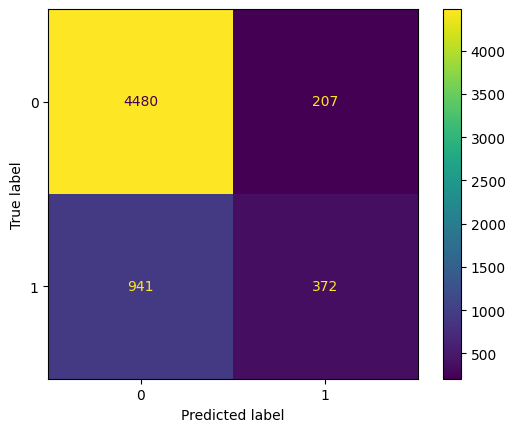

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Note:

1. The Logistic Regression model achieved an overall accuracy of 0.81 (81%), which indicates the model performs reasonably well in predicting credit card default.

2. For class 0 (non-default customers), the model performed very well with high recall (0.96). This means most non-default cases were correctly identified.

3. For class 1 (default customers), the recall is 0.28, which means the model missed many actual default cases. This happens because the dataset is imbalanced, with more non-default customers than default customers.

4. The confusion matrix shows:

4480 non-default customers correctly predicted.

207 non-default customers incorrectly predicted as default.

372 default customers correctly predicted.

941 default customers incorrectly predicted as non-default.

Overall, the model is better at predicting non-default customers than default customers.

This suggests that additional techniques or models may be needed to improve prediction of the default class.The Logistic Regression model provides a good baseline performance, but its ability to detect default cases is limited due to class imbalance in the dataset.

## Decision Tree

In [12]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [13]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7248333333333333
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4687
           1       0.38      0.40      0.39      1313

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.61      6000
weighted avg       0.73      0.72      0.73      6000



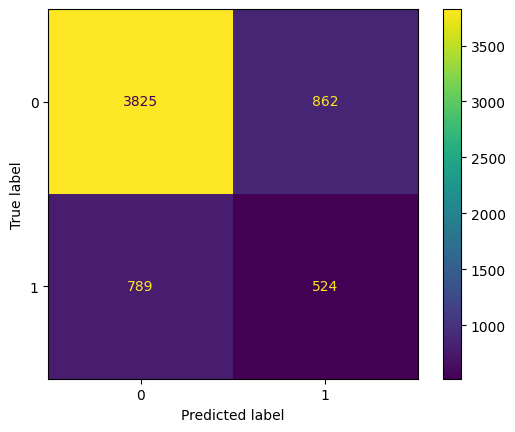

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

Note:

1. The Decision Tree model achieved an accuracy of approximately 0.72 (72%), which is lower than the Logistic Regression model.

2. For class 0 (non-default customers), the model performed reasonably well with a precision of 0.83 and recall of 0.82, meaning most non-default customers were correctly predicted.

3. For class 1 (default customers), the model performed slightly better than Logistic Regression in detecting defaults, with a recall of 0.40.

4. The confusion matrix shows:

3825 non-default customers correctly predicted.

862 non-default customers incorrectly predicted as default.

524 default customers correctly predicted.

789 default customers incorrectly predicted as non-default.

Although the Decision Tree captures more default cases than Logistic Regression, its overall accuracy is lower.

This suggests that while Decision Tree can detect more default customers, it also introduces more prediction errors. Compared to Logistic Regression, the Decision Tree model detected more default cases but produced lower overall accuracy, indicating that further model comparison is needed.

## Random Forest

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [16]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8168333333333333
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.38      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



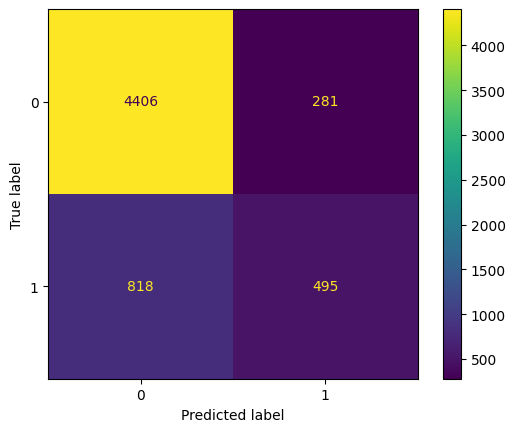

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

Note:

1. The Random Forest model achieved an accuracy of approximately 0.82 (82%), which is the highest among the tested models.

2. For class 0 (non-default customers), the model performed very well with a recall of 0.94, meaning most non-default customers were correctly identified.

3. For class 1 (default customers), the recall is 0.38, which shows the model was able to detect more default cases than Logistic Regression but still missed some default customers.

4. The confusion matrix shows:

4406 non-default customers correctly predicted.

281 non-default customers incorrectly predicted as default.

495 default customers correctly predicted.

818 default customers incorrectly predicted as non-default.

Compared to Logistic Regression and Decision Tree, Random Forest achieved the best overall performance, making it the most suitable model for this dataset.

### Model Performance Comparison

In [18]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

comparison

,Model,Accuracy
0,Logistic Regression,0.808667
1,Decision Tree,0.724833
2,Random Forest,0.816833


Note:

1. Three machine learning models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

2. The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix to understand their prediction performance.

3. Logistic Regression achieved an accuracy of 0.81. It correctly predicted 4480 non-default customers but detected only 372 default customers, showing lower recall for the default class.

4. Decision Tree achieved an accuracy of 0.72. It correctly predicted 3825 non-default customers and 524 default customers, but overall accuracy was lower compared to the other models.

5. Random Forest achieved the highest accuracy of 0.82. It correctly predicted 4406 non-default customers and 495 default customers. The weighted F1-score was 0.80, which is higher than the other models.

Based on the evaluation results, Random Forest was selected as the best model for predicting credit card default because it achieved the highest accuracy and overall balanced performance compared to the other models.

## Feature importance based on Random Forest

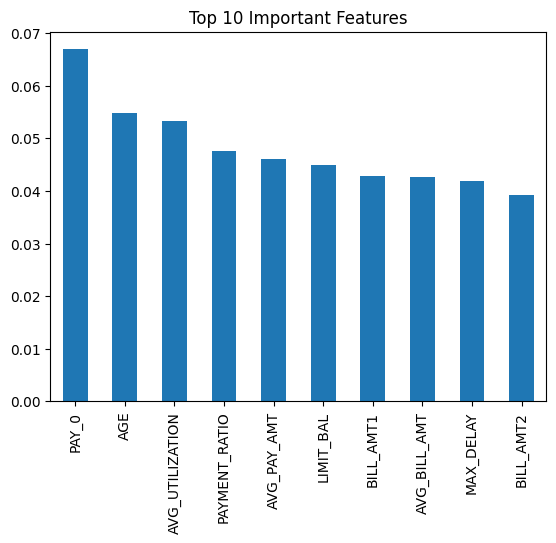

In [19]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

Note:

1. The feature importance chart shows which variables had the most influence on the Random Forest model’s predictions.

2. PAY_0 is the most important feature because it represents the most recent payment status, which strongly indicates whether a customer may default.

3. AGE is also important because different age groups may have different credit usage and repayment behaviors.

4. AVG_UTILIZATION is important because it shows how much credit limit a customer is using, and high utilization may indicate higher financial risk.

5. PAYMENT_RATIO is important because it compares how much a customer pays relative to their bill amount, reflecting repayment behavior.

6. Features like AVG_PAY_AMT and LIMIT_BAL also contribute because they represent payment capacity and credit limit.

7. Features appearing near the end, such as MAX_DELAY and BILL_AMT2, have lower importance values, meaning they contribute less to the model’s predictions.

8. Overall, the model relied more on payment behavior and credit usage features when predicting credit card default.

### Summary

The model suggests that customers with recent payment delays and high credit utilization have a higher risk of default. Financial institutions can use this information to identify high-risk customers and manage credit risk more effectively.

In [20]:
import joblib

In [21]:
joblib.dump(rf_model, "../model/random_forest_model.pkl")
print("Model saved successfully")

Model saved successfully


In [22]:
joblib.dump(X.columns.tolist(), "../model/model_features.pkl")
print("Feature columns saved")

Feature columns saved


In [23]:
# save scaler
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']